In [29]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
def extraer_negativos_xml(img, xml_path):
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    negativos = []

    for obj in root.findall("object"):
        clase = obj.find("name").text

        if clase == "Person":
            continue 

        box = obj.find("bndbox")
        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        crop = img[ymin:ymax, xmin:xmax]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (64,128))
        negativos.append(crop)

    return negativos

In [7]:
def extraer_positivos(img, xml_path):
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    positivos = []

    for obj in root.findall("object"):
        if obj.find("name").text != "Person":
            continue

        box = obj.find("bndbox")
        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        crop = img[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (64,128))
        positivos.append(crop)

    return positivos

In [11]:
X = []
y = []
hog = cv2.HOGDescriptor(
    (64,128), (16,16), (8,8), (8,8), 9
)
def get_svm_detector(svm):
    sv = svm.getSupportVectors()
    rho, _, _ = svm.getDecisionFunction(0)
    return np.append(sv.flatten(), -rho)

In [ ]:
img_dir = "Person-detection-7/train"
xml_dir = "Person-detection-7/train"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    
    positivos = extraer_positivos(img, xml_path)
    for p in positivos:
        feat = hog.compute(cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)).flatten()
        X.append(feat)
        y.append(1)
    


In [13]:
img_dir = "street-objects-3/train"
xml_dir = "street-objects-3/train"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
        
    negativos = extraer_negativos_xml(img, xml_path)

    for n in negativos:
        feat = hog.compute(cv2.cvtColor(n, cv2.COLOR_BGR2GRAY)).flatten()
        X.append(feat)
        y.append(0)
    

In [14]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

In [15]:
svm = cv2.ml.SVM_create()
svm.setType(cv2.ml.SVM_C_SVC)
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setC(0.01)
svm.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 1000, 1e-6))

svm.train(X, cv2.ml.ROW_SAMPLE, y)

svm.save("svm_personas.yml")

In [16]:
_, preds = svm.predict(X)
acc = np.mean(preds.flatten() == y)
print(f"Accuracy (train): {acc:.2f}")


Accuracy (train): 0.95


In [ ]:
img = cv2.imread("Person-detection-7/test/premium_photo-1661292128559-ec5206d3a05a_jpg.rf.a6d7515b6fb07b4cbdf140c4d2fb45f0.jpg")

rects, weights = hog.detectMultiScale(
    img,
    winStride=(8,8),
    padding=(8,8),
    scale=1.05
)

for (x,y,w,h) in rects:
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

cv2.imwrite("resultado.jpg", img)
print("📸 Resultado guardado")


In [32]:
X_test = []
y_test = []
hog = cv2.HOGDescriptor(
    (64,128), (16,16), (8,8), (8,8), 9
)

img_dir = "Person-detection-7/test"
xml_dir = "Person-detection-7/test"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    
    positivos = extraer_positivos(img, xml_path)
    for p in positivos:
        feat = hog.compute(cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)).flatten()
        X_test.append(feat)
        y_test.append(1)
    


In [33]:
img_dir = "street-objects-3/test"
xml_dir = "street-objects-3/test"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
        
    negativos = extraer_negativos_xml(img, xml_path)

    for n in negativos:
        feat = hog.compute(cv2.cvtColor(n, cv2.COLOR_BGR2GRAY)).flatten()
        X_test.append(feat)
        y_test.append(0)
    

In [34]:
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.int32)

In [24]:
img = cv2.imread("Person-detection-7/test/GX010023_frame_05385_left_jpg.rf.e9293567015119fd1aece235ab6199aa.jpg")

rects, weights = hog.detectMultiScale(
    img,
    winStride=(8,8),
    padding=(8,8),
    scale=1.05
)

for (x, y, w, h) in rects:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)

cv2.imwrite("resultado_svm.jpg", img)


True

In [30]:
_, preds = svm.predict(X_test)
acc = np.mean(preds.flatten() == y_test) 
print(f"Accuracy (test): {acc:.2f}")

Accuracy (test): 0.97


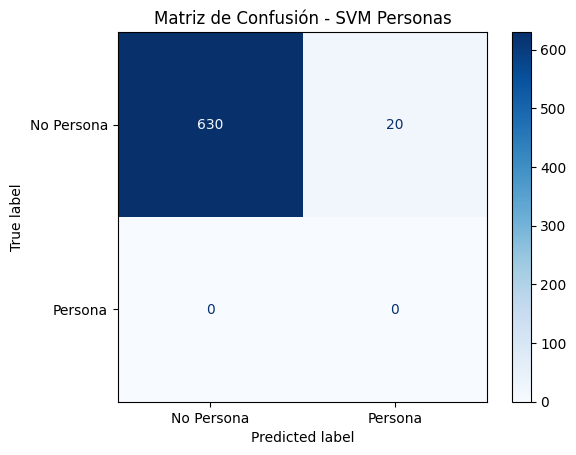

In [35]:
cm = confusion_matrix(y_test, preds, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Persona", "Persona"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - SVM Personas")
plt.show()


In [ ]:
svm = cv2.ml.SVM_load("svm_personas.yml")
hog.setSVMDetector(get_svm_detector(svm))